<a href="https://colab.research.google.com/github/vicmgarcia877/sprint7-final-project/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head()


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum )
print(users.isna().mean())

<bound method NDFrame._add_numeric_operations.<locals>.sum of       user_id  first_name  last_name    age   city  reg_date   plan  \
0       False       False      False  False  False     False  False   
1       False       False      False  False  False     False  False   
2       False       False      False  False  False     False  False   
3       False       False      False  False  False     False  False   
4       False       False      False  False  False     False  False   
...       ...         ...        ...    ...    ...       ...    ...   
3995    False       False      False  False  False     False  False   
3996    False       False      False  False  False     False  False   
3997    False       False      False  False  False     False  False   
3998    False       False      False  False  False     False  False   
3999    False       False      False  False  False     False  False   

      churn_date  
0           True  
1           True  
2           True  
3        

In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum )
print(usage.isna().mean())

<bound method NDFrame._add_numeric_operations.<locals>.sum of           id  user_id   type   date  duration  length
0      False    False  False  False     False    True
1      False    False  False  False      True   False
2      False    False  False  False      True   False
3      False    False  False  False     False    True
4      False    False  False  False     False    True
...      ...      ...    ...    ...       ...     ...
39995  False    False  False  False     False    True
39996  False    False  False  False     False    True
39997  False    False  False  False     False    True
39998  False    False  False  False      True   False
39999  False    False  False  False     False    True

[40000 rows x 6 columns]>
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

**Para el Dataset:users:**

-Columna "city" 11.72% de nulos imputaría un valor como Unknown.

-Columna "churndate" 88.35% de nulos, los ignoraría  tomando en consideración que un NaN corresponde a un cliente activo

**Para el Dataset:usage:**

-Columna "duration" 55.19% de nulos, los ignoraría ya que los NaN dependen del tipo=llamadas

-Columna "length" 44.74% de nulos , los ignoraría ya que los NaN dependen del tipo=mensajes de texto

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` no se observan valores faltantes al igual que estadísticamente no aporta un valor analítico.
- La columna `age` presenta sentinels -999, mientras que la mayoría de edades se concentra entre 32-63 años.

In [ ]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` son un identificador secuencial y de usuario respectivamente, para ambos no hay valores faltantes y no aportan un valores para el análisis estadístico pero si son útiles para relacionar datasets.
- Las columna "duration" presenta valores de 0 a 120 con una mediana de 3.5.  Los valores en 0 indican ausencia de llamadas o registros no aplicables.
- La columna "length" va de 0 a 1490 caracteres, con mediana de 50, los valores 0 pueden representar mensajes vacíos o datos no aplicables.

In [ ]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users[columnas_user].describe())


          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595


- La columna `city` tiene 7 categorías, y existen valores faltantes (<4000), la ciudad más frecuente es Bogotá y se repite 808 veces en los registros.
- La columna `plan` tiene 2 categorías sin valores faltantes, siendo el plan básico el más común con una frecuencia de 2595 veces en los registros.

In [ ]:
# explorar columna categórica de usage
usage['type'].describe() # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type' tiene 2 categorías, sin valores faltantes y la categoría mas frecuente es texto, lo cual implica un mayor uso de mensajería vs llamadas.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

  **Para age:**
  Se identificarons sentinels -999, los reemplazaría por la mediana.

  **Para duration/legnth**
  Valores en cero, los mantendría ya que representan ausencia de actividad.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
# completa el código
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [ ]:
# Convertir a fecha la columna `date` de usage
# completa el código
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

**En `reg_date`:**

Se identificaron años fuera de rangos, registros con año 2026.

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()


2024.0    39950
Name: date, dtype: int64

**En `date`:**

Todos los registros corresponden al año 2024, porlo que no se detectan fechas fuera de rango

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

**Si aparecen años imposibles específicamente 2026 para reg_date, lo cual es  un año futuro, tomando en consideración que los registros llegan hasta 2024. Se sugiere reemplazar por valores nulos (NaT) para evitar eliminar registros.**

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)
# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city']=users['city'].replace('?',pd.NA)

# Verificar cambios
(users['city']=='?').sum()

0

In [ ]:
# Marcar fechas futuras como NA para reg_date

users.loc[users['reg_date'].dt.year>2024,'reg_date'] = pd.NaT
# Verificar cambios
users['reg_date'].dt.year.value_counts()



2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean())


type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().mean())

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Se observa que la proporción de valores nulos en la columna duration depende directamente de la variable type, para el tipo call no existen valores nulos 0%.

Algo similar ocurre con la columna length la cual depende de type, para el tipo text no existen valores nulos 0%

**Para ambas columnas y por la naturaleza de los datos es normal que sean nulos, como tal se mantienen estos valores sin necesidad de imputarlos**

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text':'sum',
    'is_call':'sum',
    'duration':'sum'}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:

# Renombrar columnas
usage_agg = usage_agg.rename(columns={"is_text":"cant_mensajes","is_call":"cant_llamadas","duration":"cant_minutos_llamada"})
# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users,usage_agg, on=['user_id'], how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.122250,5.524381,4.478120,23.317054
std,1154.844867,17.690408,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,47.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].describe()

count       4000
unique         2
top       Basico
freq        2595
Name: plan, dtype: object

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

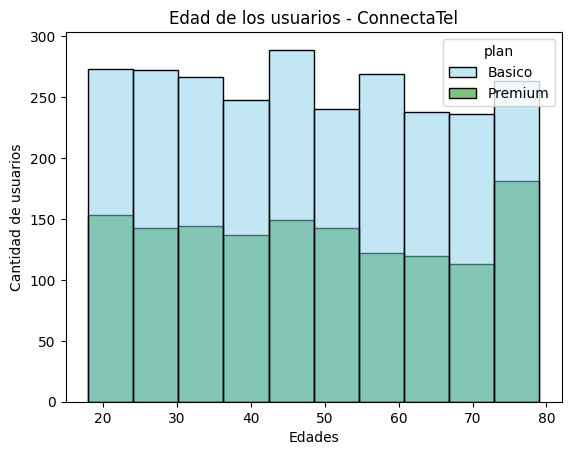

In [ ]:

# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', bins=10, palette=['skyblue', 'green'])
plt.xlabel('Edades')
plt.ylabel('Cantidad de usuarios')
plt.title('Edad de los usuarios - ConnectaTel')
plt.show()


**💡Insights: **

La distribución de edades es bastante uniforme en ambos planes, sin concentrarse en un grupo específico. No se observa una diferencia clara entre Básico y Premium, ni un sesgo marcado hacia edades jóvenes o mayores.


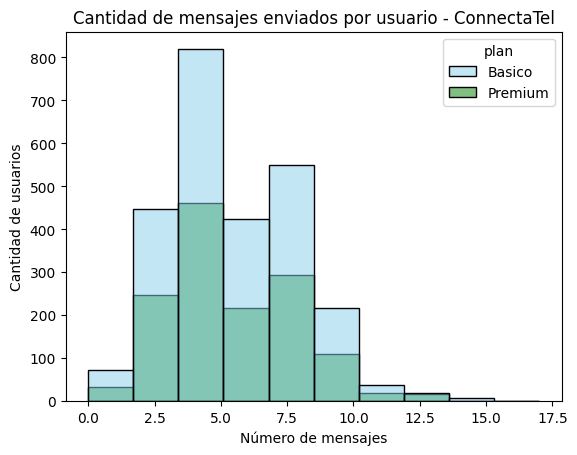

In [ ]:
# Histograma para visualizar la cant_mensajes


sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', bins=10, palette=['skyblue', 'green'])

plt.xlabel('Número de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.title('Cantidad de mensajes enviados por usuario - ConnectaTel')

plt.show()


💡Insights:

En la cantidad de mensajes, los usuarios del plan Premium tienden a enviar más mensajes y presentan mayor dispersión. La distribución muestra un ligero sesgo hacia la derecha, ya que hay pocos usuarios con valores altos.

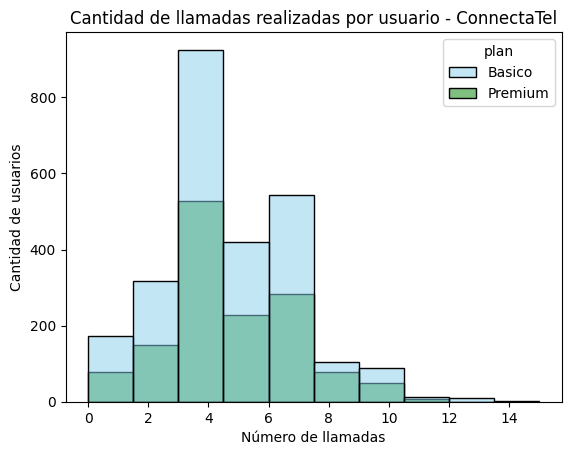

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', bins=10, palette=['skyblue','green'])
plt.xlabel('Número de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.title('Cantidad de llamadas realizadas por usuario - ConnectaTel')
plt.show()



💡Insights:

Para las llamadas, ambos planes se concentran en rangos bajos a moderados, aunque el plan Premium presenta ligeramente más uso. La distribución también tiene un sesgo hacia la derecha.

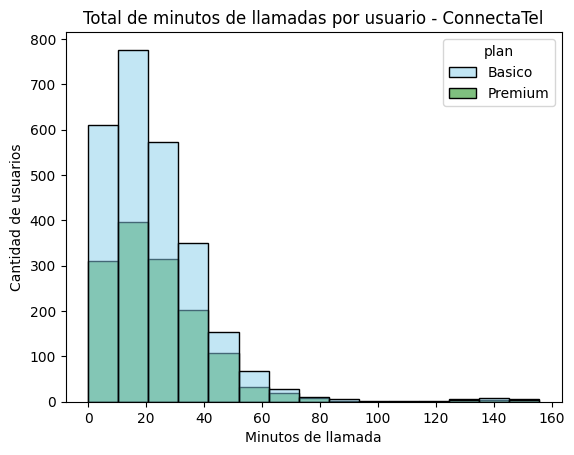

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', bins=15, palette=['skyblue','green'])
plt.xlabel('Minutos de llamada')
plt.ylabel('Cantidad de usuarios')
plt.title('Total de minutos de llamadas por usuario - ConnectaTel')

plt.show()

💡Insights:

En los minutos de llamada, la mayoría de los usuarios se mantiene en valores bajos, pero el plan Premium destaca por tener usuarios con consumos más altos. Aquí se observa un sesgo claro hacia la derecha debido a valores extremos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

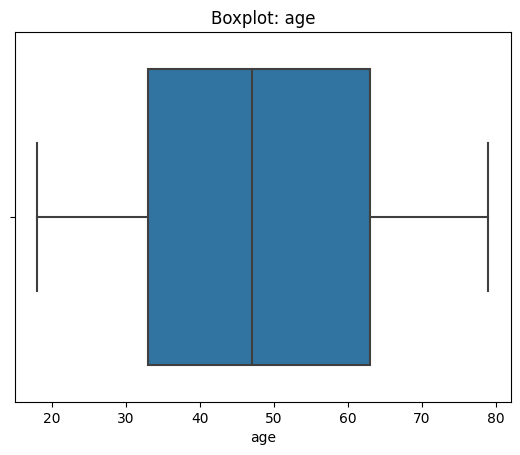

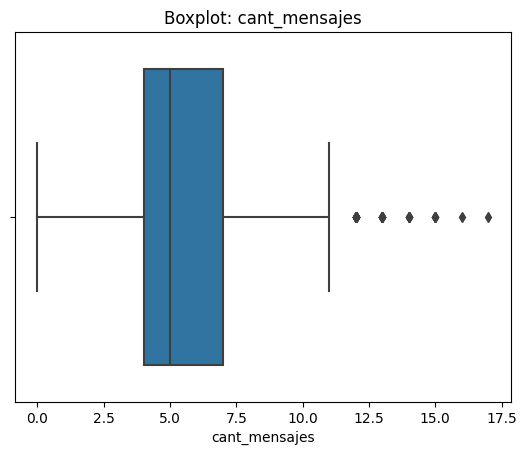

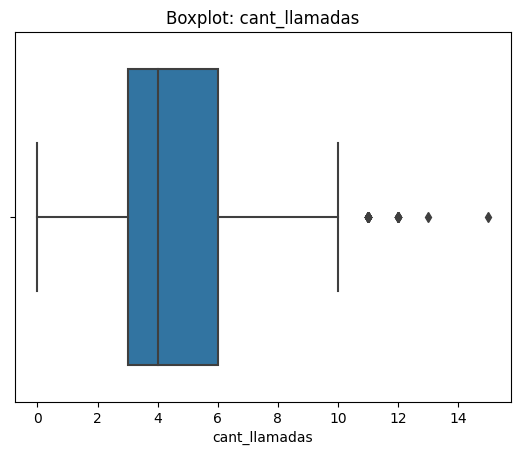

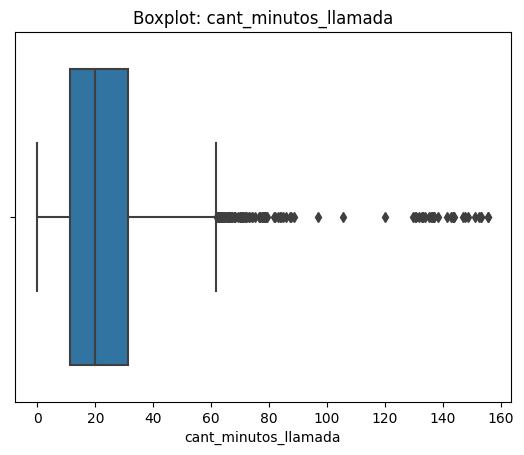

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile,x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()


💡Insights:
- Age: no se observan outliers, ya que los valores se encuentran dentro de un rango esperado.
- cant_mensajes: se identifican algunos outliers en la parte superior, lo que indica que hay usuarios que envían una cantidad de mensajes mayor al promedio.
- cant_llamadas:se observan outliers en valores altos, lo que sugiere que algunos usuarios realizan más llamadas que la mayoría.
- cant_minutos_llamada: se identifican varios outliers en la parte superior, mostrando que existen usuarios con un consumo muy alto de minutos en comparación con el resto.

In [ ]:
# Calcular límites con el método IQR
#edad no se incluye porque no hay outliers.
columnas_limites = ['cant_mensajes','cant_llamadas','cant_minutos_llamada']
for col in columnas_limites:
    Q1=user_profile[col].quantile(0.25)
    Q3=user_profile[col].quantile(0.25)
    IQR=Q3-Q1
    upper=Q3+1.5*IQR
    print(f"{col}")
    print(f"upper: {upper}")
    print("-"*30)



cant_mensajes
upper: 4.0
------------------------------
cant_llamadas
upper: 3.0
------------------------------
cant_minutos_llamada
upper: 11.12
------------------------------


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: el límite superior es 4.0 mientras que el valor máximo es 17, lo que indica una diferencia considerable. Sin embargo, estos valores altos pueden representar usuarios con mayor actividad, por lo que se decide mantenerlos.
- cant_llamadas: el límite superior es 3.0 y el valor máximo es 15. Aunque existe una diferencia importante, estos valores siguen siendo posibles dentro del comportamiento de uso, por lo que se conservan.
- cant_minutos_llamada: el límite superior es 11.12 y el valor máximo alcanza aproximadamente 155.69, mostrando una gran dispersión. A pesar de esto, estos valores reflejan usuarios con uso intensivo del servicio, por lo que se decide mantenerlos.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    "Bajo uso",
    np.where(
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
        "Uso medio",
        "Alto uso"))



In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    (user_profile['age'] < 30),"Joven",
    np.where((user_profile['age'] < 60),
        "Adulto",
        "Adulto Mayor"))


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

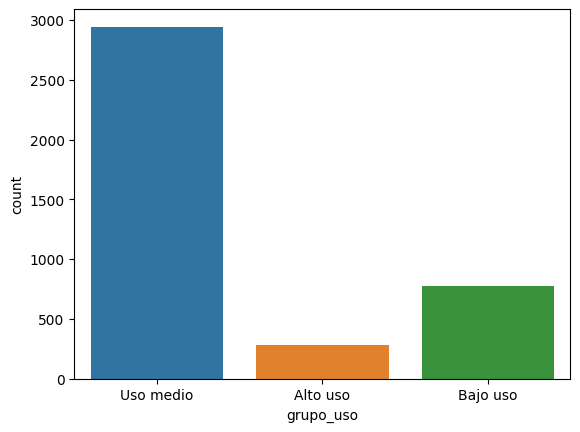

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile,x='grupo_uso')
plt.show()

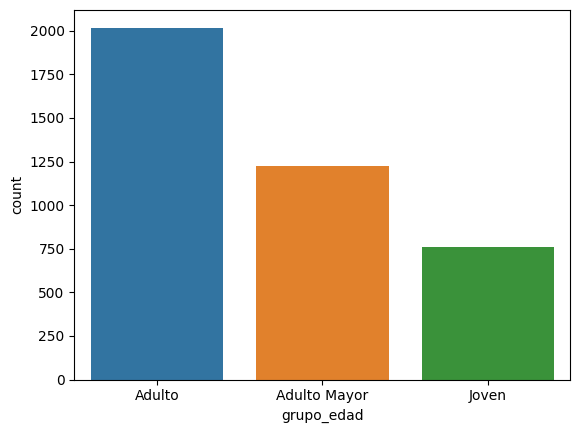

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile,x='grupo_edad')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

  
Se identificaron valores faltantes en distintas columnas, principalmente en duration y length, con proporciones cercanas al 45–55%, lo que indica ausencia de registro dependiendo del tipo de interacción (llamada o mensaje). Estos valores se mantuvieron como nulos al representar comportamientos reales (por ejemplo, mensajes sin duración o llamadas sin longitud de texto).
También se detectaron valores inválidos en age (sentinel -999), los cuales fueron reemplazados por la mediana para no sesgar el análisis. En city se identificaron valores desconocidos (“?”), que se trataron como nulos. Se encontraron fechas fuera de rango (años futuros como 2026), las cuales fueron marcadas como valores nulos (pd.NA) para evitar inconsistencias.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
  
Se identifican tres grupos principales: jóvenes, adultos y adultos mayores. La mayor concentración de usuarios se encuentra en el grupo de adultos, seguido por adultos mayores, mientras que los jóvenes representan la menor proporción, esto sugiere que la base de clientes de ConnectaTel está compuesta principalmente por usuarios en etapas medias y avanzadas de vida, lo que puede influir en los patrones de consumo y preferencias de servicio.

El segmento predominante es el de uso medio, seguido por el grupo de bajo uso, mientras que el alto uso representa una proporción menor pero relevante, esto indica que la mayoría de los usuarios tienen un consumo moderado de servicios, mientras que existe un grupo reducido con uso intensivo que podría ser clave para estrategias de valor.


- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

  
Los usuarios de alto uso parecen ser los más valiosos para ConnectaTel, ya que concentran un mayor consumo tanto en llamadas como en minutos, lo que se traduce en mayores ingresos potenciales. Aunque representan una menor proporción de la base de clientes, su nivel de actividad indica una alta dependencia del servicio. El segmento de uso medio también es relevante, ya que constituye la mayoría de los usuarios y representa una oportunidad estratégica para incrementar su consumo y convertirlos en clientes de alto valor.

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

Los outliers detectados en minutos de llamadas reflejan usuarios con consumo intensivo, lo cual puede aprovecharse para identificar perfiles de alto valor.

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

Se recomienda diseñar estrategias diferenciadas por segmento. Para usuarios de bajo uso, se pueden implementar promociones o incentivos que fomenten mayor interacción (por ejemplo, paquetes con beneficios adicionales). Para los usuarios de uso medio, se pueden ofrecer planes optimizados que refuercen su consumo actual.

Por otro lado, los usuarios de alto uso representan un segmento valioso, por lo que se recomienda desarrollar planes premium o personalizados que maximicen su retención y rentabilidad.



✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se identificaron valores faltantes en las columnas duration y length, con proporciones cercanas al 45–55%. Estos valores no representan errores, sino ausencia de registro dependiendo del tipo de interacción (llamadas o mensajes), por lo que se mantuvieron como nulos.
- Se detectaron valores inválidos en age (sentinel -999), los cuales fueron reemplazados por la mediana para evitar sesgos. Asimismo, en city se encontraron valores desconocidos (“?”), que fueron tratados como valores nulos, y fechas fuera de rango (años como 2026), las cuales se marcaron como pd.NA.


🔍 **Segmentos por Edad**
- La mayor parte de los usuarios se concentra en el grupo de adultos, seguido por adultos mayores, mientras que los jóvenes representan la menor proporción.
- Esto indica que la base de clientes de ConnectaTel está compuesta principalmente por usuarios en etapas medias y avanzadas de vida, lo que puede influir en patrones de consumo más estables y constantes.


📊 **Segmentos por Nivel de Uso**
- El segmento predominante es el de uso medio, seguido por el de bajo uso, mientras que el grupo de alto uso es el menos frecuente pero estratégico.
- Los usuarios de alto uso, aunque son pocos, presentan mayor actividad en llamadas y minutos, lo que los convierte en un segmento clave para la generación de ingresos.


➡️ Esto sugiere que:
- ConnectaTel cuenta con una base sólida de usuarios de consumo medio que pueden ser potencialmente escalados a niveles más altos de uso mediante estrategias comerciales adecuadas.
- Además, existe un segmento reducido pero altamente valioso de usuarios intensivos, así como una oportunidad clara de activar a los usuarios de bajo uso.


💡 **Recomendaciones**
- Diseñar planes diferenciados por nivel de uso: promociones para usuarios de bajo uso, optimización de planes para usuarios de uso medio y ofertas premium para usuarios de alto consumo.
- Aprovechar los patrones de uso extremo (outliers), especialmente en minutos de llamadas, para identificar clientes de alto valor y ofrecerles beneficios personalizados que aumenten su retención.
-  Implementar estrategias de segmentación más precisas que permitan adaptar la oferta comercial según el comportamiento del cliente, mejorando así la experiencia del usuario y la rentabilidad del negocio.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`